In [2]:
# Exploratory Data Analysis (EDA) - AgriPrice AI

# This notebook provides interactive exploration and visualization of price patterns, seasonal trends, and relationships.

## Analysis Goals:
# 1. **Trend Analysis** - Price movements over time
# 2. **Seasonality** - Monthly/quarterly patterns
# 3. **Distribution** - Price range and variability
# 4. **Correlation** - Feature relationships for modeling

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Load processed data
notebook_dir = os.getcwd()
base_dir = os.path.dirname(notebook_dir)
processed_data_path = os.path.join(base_dir, "data", "processed_data.csv")
data = pd.read_csv(processed_data_path, parse_dates=["Date"])

print(f"✅ Loaded processed data: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print(f"\nColumns: {list(data.columns)}")

✅ Loaded processed data: (7, 15)
Date range: 2022-01-01 00:00:00 to 2022-01-07 00:00:00

Columns: ['Date', 'Commodity', 'Price', 'Volume', 'price_lag_7', 'price_lag_14', 'price_lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'month', 'quarter', 'year', 'is_harvest_season', 'is_festival_season']


1. PRICE TREND ANALYSIS


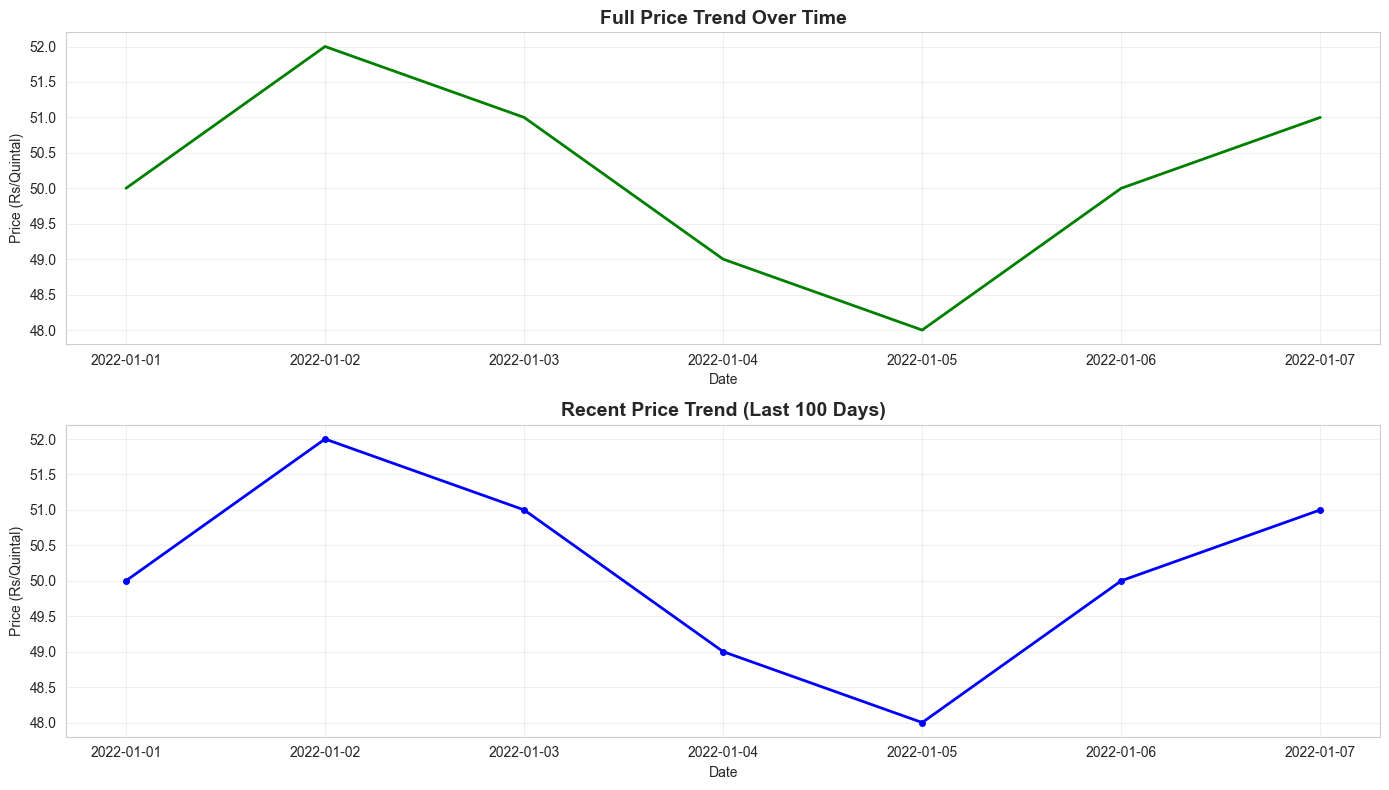


Price Statistics:
  Min: Rs.48.00
  Max: Rs.52.00
  Mean: Rs.50.14
  Std Dev: Rs.1.35


In [4]:
## 1. Price Trend Over Time
print("=" * 60)
print("1. PRICE TREND ANALYSIS")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Full trend
ax1.plot(data["Date"], data["Price"], color="green", linewidth=2)
ax1.set_title("Full Price Trend Over Time", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (Rs/Quintal)")
ax1.grid(True, alpha=0.3)

# Recent trend (last 100 days if available)
recent_data = data.tail(min(100, len(data)))
ax2.plot(recent_data["Date"], recent_data["Price"], color="blue", linewidth=2, marker="o", markersize=4)
ax2.set_title("Recent Price Trend (Last 100 Days)", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date")
ax2.set_ylabel("Price (Rs/Quintal)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrice Statistics:")
print(f"  Min: Rs.{data['Price'].min():.2f}")
print(f"  Max: Rs.{data['Price'].max():.2f}")
print(f"  Mean: Rs.{data['Price'].mean():.2f}")
print(f"  Std Dev: Rs.{data['Price'].std():.2f}")


2. SEASONAL PATTERN ANALYSIS


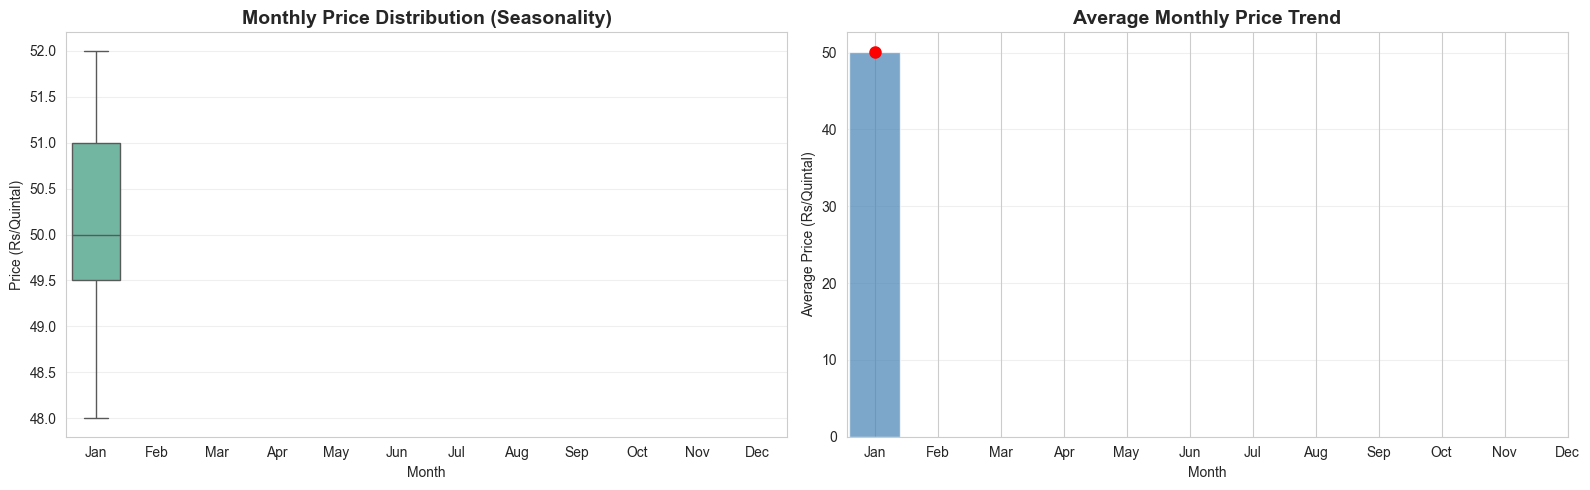


Monthly Average Prices:
  Jan: Rs.50.14
  Feb: Rs.nan
  Mar: Rs.nan
  Apr: Rs.nan
  May: Rs.nan
  Jun: Rs.nan
  Jul: Rs.nan
  Aug: Rs.nan
  Sep: Rs.nan
  Oct: Rs.nan
  Nov: Rs.nan
  Dec: Rs.nan


In [5]:
## 2. Monthly Seasonality
print("\n" + "=" * 60)
print("2. SEASONAL PATTERN ANALYSIS")
print("=" * 60)

data["month_name"] = data["Date"].dt.strftime("%b")
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Monthly boxplot
sns.boxplot(
    data=data,
    x="month_name",
    y="Price",
    hue="month_name",
    order=month_order,
    palette="Set2",
    ax=ax1,
    legend=False,
)
ax1.set_title("Monthly Price Distribution (Seasonality)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Month")
ax1.set_ylabel("Price (Rs/Quintal)")
ax1.grid(True, alpha=0.3, axis="y")

# Monthly average trend line
monthly_avg = data.groupby("month_name")["Price"].mean().reindex(month_order)
ax2.bar(range(len(monthly_avg)), monthly_avg.values, color="steelblue", alpha=0.7)
ax2.plot(range(len(monthly_avg)), monthly_avg.values, color="red", linewidth=2, marker="o", markersize=8)
ax2.set_xticks(range(len(month_order)))
ax2.set_xticklabels(month_order)
ax2.set_title("Average Monthly Price Trend", fontsize=14, fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Average Price (Rs/Quintal)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nMonthly Average Prices:")
for month, price in monthly_avg.items():
    print(f"  {month}: Rs.{price:.2f}")


4. DISTRIBUTION ANALYSIS


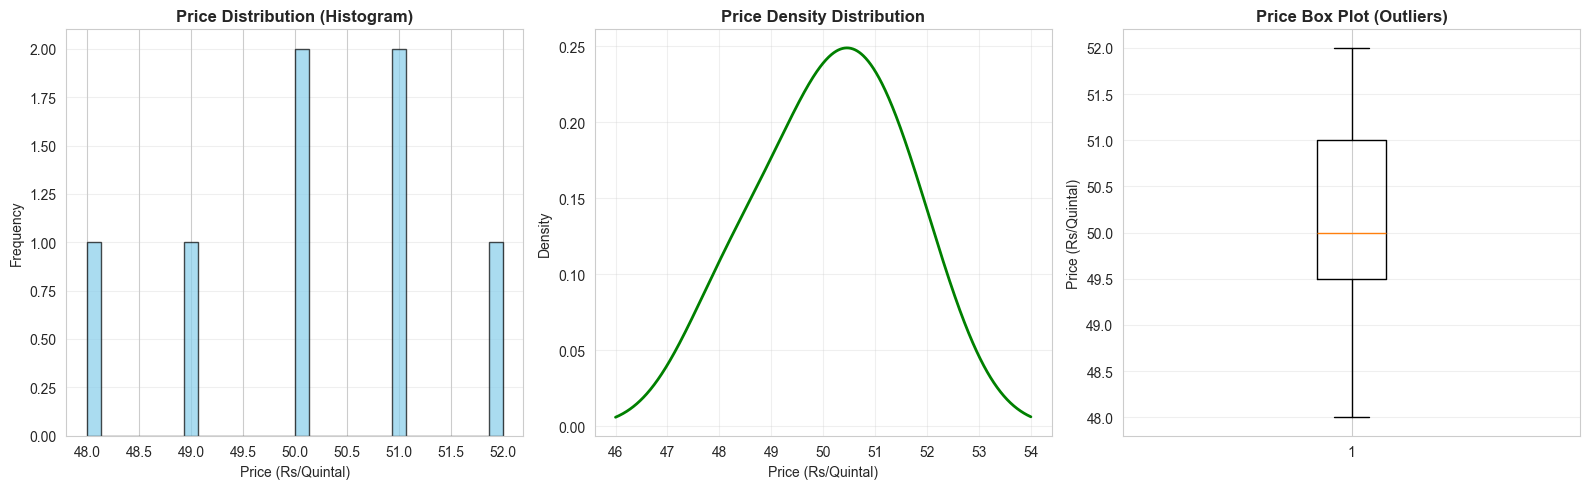


Outlier Detection:
  Q1: Rs.49.50
  Q3: Rs.51.00
  IQR: Rs.1.50
  Outliers detected: 0 (0.0%)


In [6]:
## 4. Distribution & Outliers
print("\n" + "=" * 60)
print("4. DISTRIBUTION ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(data["Price"], bins=30, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Price Distribution (Histogram)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Price (Rs/Quintal)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3, axis="y")

# KDE plot
data["Price"].plot(kind="kde", ax=axes[1], color="green", linewidth=2)
axes[1].set_title("Price Density Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Price (Rs/Quintal)")
axes[1].grid(True, alpha=0.3)

# Box plot
axes[2].boxplot(data["Price"], vert=True)
axes[2].set_title("Price Box Plot (Outliers)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Price (Rs/Quintal)")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Outlier detection
Q1 = data["Price"].quantile(0.25)
Q3 = data["Price"].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data["Price"] < Q1 - 1.5 * IQR) | (data["Price"] > Q3 + 1.5 * IQR)]

print(f"\nOutlier Detection:")
print(f"  Q1: Rs.{Q1:.2f}")
print(f"  Q3: Rs.{Q3:.2f}")
print(f"  IQR: Rs.{IQR:.2f}")
print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


3. FEATURE CORRELATION ANALYSIS


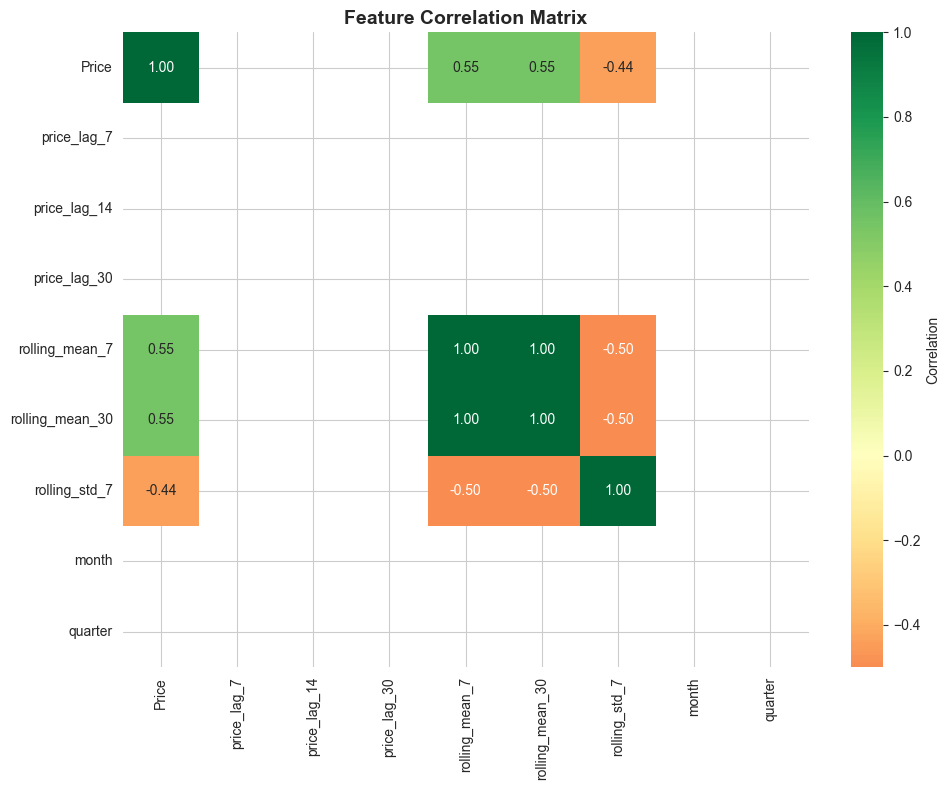


Correlation with Price (sorted):
  rolling_mean_7      : +0.5494
  rolling_mean_30     : +0.5494
  rolling_std_7       : -0.4373
  price_lag_7         : +nan
  price_lag_14        : +nan
  price_lag_30        : +nan
  month               : +nan
  quarter             : +nan


In [7]:
## 3. Feature Correlation
print("\n" + "=" * 60)
print("3. FEATURE CORRELATION ANALYSIS")
print("=" * 60)

# Select numeric columns for correlation
numeric_cols = [
    "Price",
    "price_lag_7",
    "price_lag_14",
    "price_lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",
    "month",
    "quarter",
]
available_cols = [col for col in numeric_cols if col in data.columns]

corr_matrix = data[available_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", center=0, fmt=".2f", cbar_kws={"label": "Correlation"})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nCorrelation with Price (sorted):")
price_corr = corr_matrix["Price"].sort_values(ascending=False)
for col, corr_val in price_corr.items():
    if col != "Price":
        print(f"  {col:20s}: {corr_val:+.4f}")